In [26]:
import sklearn as sk
import tensorflow as tf

In [27]:
from __future__ import absolute_import, division, print_function, unicode_literals
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import clear_output
from six.moves import urllib
import tensorflow.compat.v2.feature_column as fc

In [28]:
cols = ["Length", "Diameter", "Height", "Whole weight", "Shucked weight","Viscera weight", "Shell weight", "Age"]
dftrain = pd.read_csv("https://storage.googleapis.com/download.tensorflow.org/data/abalone_train.csv",names=cols)
dftest = pd.read_csv("https://storage.googleapis.com/download.tensorflow.org/data/abalone_test.csv",names=cols)

In [29]:
dftest.head()

,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Age
0,0.570,0.465,0.180,1.2950,0.3390,0.2225,0.440,12
1,0.660,0.530,0.185,1.3485,0.4930,0.2450,0.490,12
2,0.440,0.345,0.120,0.3650,0.1655,0.0830,0.110,7
3,0.620,0.475,0.160,1.1295,0.4630,0.2685,0.330,10
4,0.505,0.410,0.135,0.6570,0.2910,0.1330,0.195,15


<Axes: >

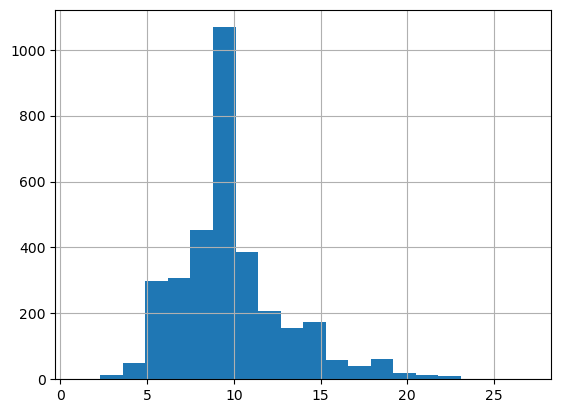

In [30]:
dftrain["Age"].hist(bins=20)

<Axes: ylabel='Height'>

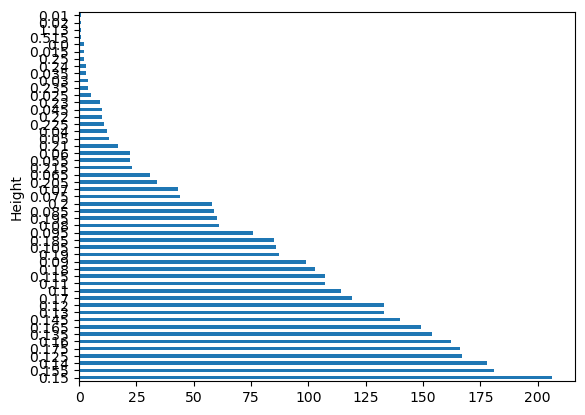

In [31]:
dftrain["Height"].value_counts().plot(kind="barh")

In [36]:
x_train = dftrain.drop("Age",axis=1)
y_train = dftrain["Age"]

In [37]:
y_train.head()

0     7
1     6
2    14
3    16
4    13
Name: Age, dtype: int64

In [38]:
from sklearn.linear_model import LinearRegression

In [39]:
model = LinearRegression()
model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [43]:
dftest = pd.read_csv("https://storage.googleapis.com/download.tensorflow.org/data/abalone_test.csv",names=cols)
x_test = dftest.drop("Age",axis=1)
y_test = dftest["Age"]
y_test.head()

0    12
1    12
2     7
3    10
4    15
Name: Age, dtype: int64

In [44]:
pred = model.predict(x_test)

In [46]:
print(pred[:5])

[17.27469445 15.52270651  8.46824607 11.49319875  9.81823018]


In [48]:
from sklearn.metrics import mean_squared_error, r2_score

In [51]:
MSE = mean_squared_error(y_test,pred)
r_score = r2_score(y_test,pred)
print(MSE) # squared diff between actual and predicted
print(r_score) # closer to 1 good model close to 0 bad model

5.523331059501297
0.4895358359812435
